In [4]:
%reload_ext autoreload
%autoreload 2

In [5]:
import datetime
import json
import os
import random

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import wandb
from accelerate.commands.config.update import description
from transformers import (
    AutoModelForMaskedLM,
    AutoTokenizer,
    EarlyStoppingCallback,
    Trainer,
    TrainingArguments,
)

def set_seed(seed=42) -> None:
    """Set all seeds to make results reproducible (deterministic mode).
    When seed is a false-y value or not supplied, disables deterministic mode."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(42)

from dotenv import load_dotenv
load_dotenv()

import sys
sys.path.append('/rhome/sawale/indus_traning/mlm-fine-tuning/mlm')

In [6]:
for i in range(torch.cuda.device_count()):
    print(torch.cuda.get_device_properties(i).name)

NVIDIA RTX A5000
NVIDIA RTX A5000
NVIDIA RTX A5000
NVIDIA RTX A5000


## Load trained model from wandb

In [7]:
def load_model_from_wandb(model_path):
    run = wandb.init()
    artifact = run.use_artifact(model_path, type='model')
    artifact_dir = artifact.download()
    model = AutoModelForMaskedLM.from_pretrained(artifact_dir)
    return model, artifact_dir

def load_model_from_local(model_path):
    model = AutoModelForMaskedLM.from_pretrained(model_path)
    return model, model_path

def load_model(model_path, use_wandb=True):
    if use_wandb:
        return load_model_from_wandb(model_path)
    else:
        return load_model_from_local(model_path)


# load models

model_0, model_0_path = load_model_from_local("nasa-impact/nasa-smd-ibm-v0.1")

## load initial model fine tuned from nasa-smd-ibm-v0.1 with 100k dataset
model_1, model_1_path = load_model_from_wandb("nasa-impact/mlm-fine-tuning/model-ytxjrbhy:v1")
tokenizer_indus = AutoTokenizer.from_pretrained("nasa-impact/nasa-smd-ibm-v0.1")

## load model fine tuned from modernbert-base with 96 dataset using random token masking
model_2, model_2_path = load_model_from_wandb("nasa-impact/mlm-fine-tuning/model-y9xrdfec:v1")
tokenizer_modernbert = AutoTokenizer.from_pretrained("answerdotai/ModernBERT-base")

## load model fine tuned from modernbert-base with 96 dataset using static keyword masking
model_3, model_3_path = load_model_from_wandb("nasa-impact/mlm-fine-tuning/model-zes5w74d:v4")

## load model fine tuned from modernbert-base with 96k dataset using dynamic keyword masking
model_4, model_4_path = load_model_from_wandb("nasa-impact/mlm-fine-tuning/model-yl3xhgco:v2")


model_5, model_5_path = load_model_from_wandb("nasa-impact/mlm-fine-tuning/model-5byuqwpd:v1")


wandb: Currently logged in as: sajil (nasa-impact) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


wandb: Downloading large artifact model-ytxjrbhy:v1, 475.71MB. 4 files... 
wandb:   4 of 4 files downloaded.  
Done. 0:0:0.8
wandb: Downloading large artifact model-y9xrdfec:v1, 570.92MB. 4 files... 
wandb:   4 of 4 files downloaded.  
Done. 0:0:1.0
You are attempting to use Flash Attention 2.0 with a model not initialized on GPU. Make sure to move the model to GPU after initializing it on CPU with `model.to('cuda')`.
wandb: Downloading large artifact model-zes5w74d:v4, 570.92MB. 4 files... 
wandb:   4 of 4 files downloaded.  
Done. 0:0:1.0
wandb: Downloading large artifact model-yl3xhgco:v2, 570.92MB. 4 files... 
wandb:   4 of 4 files downloaded.  
Done. 0:0:1.0
wandb: Downloading large artifact model-5byuqwpd:v1, 477.23MB. 4 files... 
wandb:   4 of 4 files downloaded.  
Done. 0:0:0.8


## Load Data and split identiacally

In [ ]:
from preprocess_data import preprocess_dataset, preprocess_dataset_with_kw_masking, disk_cache
with open("../config_indus.json", "r") as file:
    config_indus = json.load(file)

with open("../config_modernbert.json", "r") as file:
    config_modernbert = json.load(file)


data_src = "local"
n_rows = 1000

config_indus["input"]["dataset"]["kw_masking_type"] = {"static": True, "dynamic": False}
lm_dataset_indus, tokenizer_indus, data_collator_indus = preprocess_dataset_with_kw_masking(
        config_indus.get("input"),
        data_src,
        n_rows,
    )

config_modernbert["input"]["dataset"]["kw_masking_type"] = {"static": True, "dynamic": False}
lm_dataset_mbs, tokenizer_mbs, data_collator_mbs = preprocess_dataset_with_kw_masking(
        config_modernbert.get("input"),
        data_src,
        n_rows,
    )


model_dict = {
    "original_indus": {
        "model": model_0_path,
        "tokenizer": tokenizer_indus,
        "dataset": lm_dataset_indus,
        "config": config_indus
    },
    # "indus-sde-v0.2_stage1": {
    #     "model": model_5_path,
    #     "tokenizer": tokenizer_indus,
    #     "dataset": lm_dataset_indus,
    #     "config": config_indus
    # },
    "indus-sde-v0.1": {
        "model": model_1_path,
        "tokenizer": tokenizer_indus,
        "dataset": lm_dataset_indus,
        "config": config_indus
    },
    "modernbert-sde-v0.1 (random_masking)": {
        "model": model_2_path,
        "tokenizer": tokenizer_modernbert,
        "dataset": lm_dataset_mbs,
        "config": config_modernbert
    },
    "modernbert-sde-v0.1 (static_masking)": {
        "model": model_3_path,
        "tokenizer": tokenizer_modernbert,
        "dataset": lm_dataset_mbs,
        "config": config_modernbert
    },
    "modernbert-sde-v0.1 (dynamic_masking)": {
        "model": model_4_path,
        "tokenizer": tokenizer_modernbert,
        "dataset": lm_dataset_mbs,
        "config": config_modernbert
    }
}

num_proc must be <= 10. Reducing num_proc to 10 for dataset of size 10.


Map (num_proc=10):   0%|          | 0/10 [00:00<?, ? examples/s]

num_proc must be <= 10. Reducing num_proc to 10 for dataset of size 10.


Map (num_proc=10):   0%|          | 0/10 [00:00<?, ? examples/s]

num_proc must be <= 10. Reducing num_proc to 10 for dataset of size 10.


...

Gen Prob Matrix (num_proc=8):   0%|          | 0/19 [00:00<?, ? examples/s]

Gen Prob Matrix (num_proc=8):   0%|          | 0/27 [00:00<?, ? examples/s]

Static Masking:   0%|          | 0/12 [00:00<?, ? examples/s]

Static Masking:   0%|          | 0/19 [00:00<?, ? examples/s]

Static Masking:   0%|          | 0/27 [00:00<?, ? examples/s]

In [12]:
def get_accuracy(inference_df):
    _inference_df = inference_df.copy()
    top_n = [c for c in _inference_df.columns if "top" in c]

    _inference_df['predictions'] = _inference_df.apply(lambda row: [row[col].get('token_str') for col in top_n], axis=1)

    for i, top_i in enumerate(top_n):
        _inference_df[f'{top_i}_correct'] = _inference_df.apply(lambda row: int(row['target'] in row['predictions'][:i+1]), axis=1)

    accuracy = {top_i: float(round(_inference_df[f'{top_i}_correct'].mean(), 4)) for top_i in top_n}

    return accuracy

## Make Predictions on train and test data

In [13]:
from utils import generate_inference

In [16]:
os.makedirs("tmp/inferences", exist_ok=True)

topk_accuracies = {}
for model_name, d in model_dict.items():
        topk_accuracies[model_name] = {}
        for data_split in ["train", "test"]:
        # for data_split in ["test"]:
                print(f"Generating inferences for {model_name} on {data_split}")
                inference_df = generate_inference(
                        d["dataset"][data_split],
                        d["tokenizer"],
                        d["model"],
                        top_k=d["config"].get("output").get("inference").get("top_k"),
                        n_predictions=None,
                        max_length=d["config"].get("input").get("dataset").get("chunk_size"),
                        use_keyword_based_masking=True
                )
                accuracy = get_accuracy(inference_df)
                topk_accuracies[model_name][data_split] = accuracy
                print(accuracy)
                inference_df.to_parquet(f"tmp/inferences/{model_name}_{data_split}_inference.parquet", index=False)
        print("-"*100)
        


Generating inferences for original_indus on train


Map:   0%|          | 0/15 [00:00<?, ? examples/s]

Device set to use cuda:0


{'top1': 0.2667, 'top2': 0.2667, 'top3': 0.3333}
Generating inferences for original_indus on test


Device set to use cuda:0


...

{'top1': 0.6667, 'top2': 0.7407, 'top3': 0.8148}
----------------------------------------------------------------------------------------------------
Generating inferences for modernbert-sde-v0.1 (dynamic_masking) on train


Device set to use cuda:0


{'top1': 0.6667, 'top2': 0.75, 'top3': 0.75}
Generating inferences for modernbert-sde-v0.1 (dynamic_masking) on test


Device set to use cuda:0


{'top1': 0.5926, 'top2': 0.7778, 'top3': 0.8519}
----------------------------------------------------------------------------------------------------


In [20]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Convert dictionary to a DataFrame
data = []
for model_name, splits in topk_accuracies.items():
    for data_split, accuracies in splits.items():
        for top_k, acc in accuracies.items():
            data.append([model_name, data_split, top_k, acc])

df = pd.DataFrame(data, columns=["Model", "Dataset", "Top-K", "Accuracy"])

# Define results directory
results_dir = "results"

# Function to ensure directory exists
def ensure_directory(directory):
    if not os.path.exists(directory):
        os.makedirs(directory)
        print(f"Created directory: {directory}")

# Ensure results directory exists
ensure_directory(results_dir)


# Map each model to a unique hatch pattern
def generate_model_to_hatch(df, hatch_patterns):
    models = df["Model"].unique()
    return {model: hatch_patterns[i % len(hatch_patterns)] for i, model in enumerate(models)}

# Function to plot accuracy grouped by Top-K and save results
def plot_topk_accuracies(df, dataset, font_size=12):
    # Set color palette for models
    model_palette = sns.color_palette("colorblind", n_colors=len(df["Model"].unique()))

    # Set color palette for models
    model_palette = sns.color_palette("colorblind", n_colors=len(df["Model"].unique()))

    # Define hatch patterns
    hatch_patterns = ['/', '\\', '|', '-', '+', 'x', 'o', '*', 'O', "//", "\\\\", "||", "--", "++", "xx", "oo", "..", "**"]

    plt.figure(figsize=(10, 6))
    df_subset = df[df["Dataset"] == dataset]

    # Create model-to-hatch mapping
    model_to_hatch = generate_model_to_hatch(df_subset, hatch_patterns)
    
    ax = sns.barplot(
        data=df_subset, x="Top-K", y="Accuracy", hue="Model", palette=model_palette
    )

     # Apply hatch patterns based on model
    for p, (_, row) in zip(ax.patches, df_subset.iterrows()):
        model = row["Model"]
        p.set_hatch(model_to_hatch[model])
        p.set_edgecolor("white")
    
    # Get legend handles and labels
    handles, labels = ax.get_legend_handles_labels()
    new_handles = [
        plt.Rectangle((0, 0), 1, 1, fc=model.get_facecolor(), hatch=model_to_hatch[label], edgecolor="white")
        for model, label in zip(handles, labels)
        ]

    # Update legend with new handles
    plt.legend(
        new_handles, labels,
        loc="upper center", bbox_to_anchor=(0.5, -0.15),
        ncol=2, fontsize=font_size, frameon=False,
        handleheight=2, handlelength=3,
    )

    
    plt.title(f"Mask Filling Top-K Accuracies for {dataset.capitalize()} Set", fontsize=font_size + 2, fontweight="bold")
    plt.ylim(0, 1)
    plt.xlabel("Top-K Accuracy", fontsize=font_size, fontweight="bold")
    plt.ylabel("Accuracy", fontsize=font_size, fontweight="bold")
    
    # Add value labels
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(f"{height:.2f}", (p.get_x() + p.get_width() / 2.0, height),
                        ha="center", va="bottom", fontsize=font_size - 2, color="black", fontweight="bold")
    
    plt.tight_layout()
    
    # Save plot
    plot_path = f"{results_dir}/{dataset}_topk_accuracies.png"
    plt.savefig(plot_path, dpi=300)
    print(f"Plot saved to {plot_path}")
    
    plt.close()

    # Save data table
    table_path = f"{results_dir}/{dataset}_topk_accuracies.csv"
    df_subset.to_csv(table_path, index=False)
    print(f"Data table saved to {table_path}")

# Plot and save for Train Set
plot_topk_accuracies(df, "train")

# Plot and save for Test Set
plot_topk_accuracies(df, "test")


Plot saved to results/train_topk_accuracies.png
Data table saved to results/train_topk_accuracies.csv
Plot saved to results/test_topk_accuracies.png
Data table saved to results/test_topk_accuracies.csv


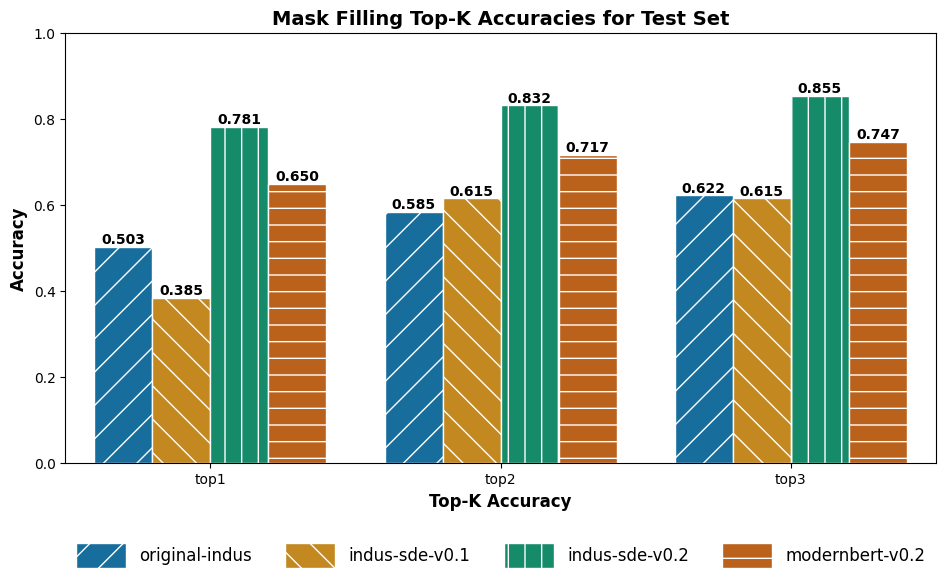

In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import hashlib

# Function to ensure directory exists
def ensure_directory(directory):
    if not os.path.exists(directory):
        os.makedirs(directory)

# Define results directory
results_dir = "results"
ensure_directory(results_dir)

# Sample dictionary for top-k accuracies
topk_accuracies = {
    "original-indus": {"test": {'top1': 0.5034, 'top2': 0.585, 'top3': 0.6224}},
    "indus-sde-v0.1": {"test": {'top1': 0.3846, 'top2': 0.6154, 'top3': 0.6154}},
    "indus-sde-v0.2": {"test": {'top1': 0.7814, 'top2': 0.8319, 'top3': 0.8548}},
    "modernbert-v0.2": {"test": {'top1': 0.6499, 'top2': 0.7169, 'top3': 0.7469}},
}

# Convert dictionary to DataFrame
data = []
for model_name, splits in topk_accuracies.items():
    for data_split, accuracies in splits.items():
        for top_k, acc in accuracies.items():
            data.append([model_name, data_split, top_k, acc])

df = pd.DataFrame(data, columns=["Model", "Dataset", "Top-K", "Accuracy"])

# Set color palette for models
model_palette = sns.color_palette("colorblind", n_colors=len(df["Model"].unique()))

# Define hatch patterns
hatch_patterns = ['/', '\\', '|', '-', '+', 'x', 'o', '*', 'O', "//", "\\\\", "||", "--", "++", "xx", "oo", "..", "**"]

# Map each model to a unique hatch pattern
def generate_model_to_hatch(df, hatch_patterns):
    models = df["Model"].unique()
    return {model: hatch_patterns[i % len(hatch_patterns)] for i, model in enumerate(models)}

# Plot top-k accuracies
def plot_topk_accuracies(df, dataset, font_size=12):
    plt.figure(figsize=(10, 6))
    df_subset = df[df["Dataset"] == dataset]
    
    # Create model-to-hatch mapping
    model_to_hatch = generate_model_to_hatch(df_subset, hatch_patterns)

    ax = sns.barplot(
        data=df_subset, x="Top-K", y="Accuracy", hue="Model", palette=model_palette
    )

    # Apply hatch patterns based on model
    for p, (_, row) in zip(ax.patches, df_subset.iterrows()):
        model = row["Model"]
        p.set_hatch(model_to_hatch[model])
        p.set_edgecolor("white")
    
    # Get legend handles and labels
    handles, labels = ax.get_legend_handles_labels()
    new_handles = [
        plt.Rectangle((0, 0), 1, 1, fc=model.get_facecolor(), hatch=model_to_hatch[label], edgecolor="white")
        for model, label in zip(handles, labels)
        ]

    # Update legend with new handles
    plt.legend(
        new_handles, labels,
        loc="upper center", bbox_to_anchor=(0.5, -0.15),
        ncol=4, fontsize=font_size, frameon=False,
        handleheight=2, handlelength=3,
    )
    
    plt.title(f"Mask Filling Top-K Accuracies for {dataset.capitalize()} Set", fontsize=font_size + 2, fontweight="bold")
    plt.ylim(0, 1)
    plt.xlabel("Top-K Accuracy", fontsize=font_size, fontweight="bold")
    plt.ylabel("Accuracy", fontsize=font_size, fontweight="bold")
    
    # Add value labels
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(f"{height:.3f}", (p.get_x() + p.get_width() / 2.0, height),
                        ha="center", va="bottom", fontsize=font_size - 2, color="black", fontweight="bold")
    
    plt.tight_layout()
    plt.show()

# Plot and save for Test Set
plot_topk_accuracies(df, "test")


(97369, 17)